In [23]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive')
print("✅ Google Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


In [4]:
import subprocess
import os

# Extract sprint3 source data ONLY
print("Extracting sprint3_source_data.zip...")
result = subprocess.run(['unzip', '-q', 'sprint3_source_data.zip'],
                       capture_output=True, text=True)

if result.returncode == 0:
    print("✅ Extraction successful")
else:
    print(f"❌ Error: {result.stderr}")
    # Try alternate extraction
    subprocess.run(['python', '-m', 'zipfile', '-e', 'sprint3_source_data.zip', '.'], check=True)

# Verify
if os.path.exists('data/sprint3_source'):
    print("✅ sprint3_source extracted successfully")
    os.system('ls -lh data/sprint3_source/ | head -10')
    print(f"Total batches: {len([d for d in os.listdir('data/sprint3_source') if 'batch' in d])}")
else:
    print("❌ Extraction failed - checking directory...")
    os.system('ls -lh')

Extracting sprint3_source_data.zip...
❌ Error: replace data/sprint3_source/batch_0016/images.pt? [y]es, [n]o, [A]ll, [N]one, [r]ename:  NULL
(EOF or read error, treating as "[N]one" ...)

✅ sprint3_source extracted successfully
Total batches: 20


In [5]:
import torch
import subprocess

# Check GPU
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("⚠️ Running on CPU - AdvGAN will be slower")

# Install dependencies
print("\nInstalling dependencies...")
subprocess.run(['pip', 'install', '-q', 'foolbox', 'adversarial-robustness-toolbox', 'tqdm'], check=True)

print("✅ All dependencies installed")

GPU Available: True
GPU: Tesla T4
CUDA: 12.6

Installing dependencies...
✅ All dependencies installed


In [6]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms.functional as TF
import numpy as np
from pathlib import Path
import json
import logging
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")

# Create output directory
output_dir = Path('outputs/sprint3_realistic')
output_dir.mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")

✅ Setup complete


In [7]:
import torch
from torchvision import models
from torchvision.models import ResNet50_Weights
import logging

# Setup logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
logger = logging.getLogger(__name__)

# -------------------- 1️⃣ Set device --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Loading ResNet50 on {device}...")

# -------------------- 2️⃣ Load pretrained ResNet50 --------------------
# Use the recommended 'weights' argument instead of 'pretrained=True'
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model.eval()
model = model.to(device)

# -------------------- 3️⃣ Test with dummy input --------------------
dummy = torch.randn(1, 3, 224, 224, device=device)  # create tensor directly on device
with torch.no_grad():
    output = model(dummy)

print(f"✅ ResNet50 loaded successfully")
print(f"   Output shape: {output.shape}")


✅ ResNet50 loaded successfully
   Output shape: torch.Size([1, 1000])


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Generator(nn.Module):
    """GAN Generator for wearable patches (64x64 output)"""

    def __init__(self, noise_dim=100, output_channels=3):
        super().__init__()
        self.noise_dim = noise_dim

        # Fully connected layers with LayerNorm (batch-size independent)
        self.fc = nn.Sequential(
            nn.Linear(noise_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 256 * 4 * 4),  # 256 channels, 4x4 feature map
            nn.LayerNorm(256 * 4 * 4),
            nn.ReLU(inplace=True)
        )

        # Deconv layers to reach 64x64
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 4x4 -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 8x8 -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 16x16 -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, output_channels, 4, 2, 1),  # 32x32 -> 64x64
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)  # reshape for deconv
        x = self.deconv(x)
        return x

# -------------------- Test --------------------
gen = Generator()
gen.eval()  # important for single-sample testing
dummy = torch.randn(1, 100)
out = gen(dummy)
print(f"✅ Output shape: {out.shape}")  # should print: torch.Size([1, 3, 64, 64])


✅ Output shape: torch.Size([1, 3, 64, 64])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datetime import datetime

class AdvGANWearableGenerator:
    """Generate AdvGAN wearable patches (64x64 output)"""

    def __init__(self, target_model, device='cuda', noise_dim=100):
        self.device = device
        self.target_model = target_model

        # Use the fixed Generator (64x64 output)
        self.generator = Generator(noise_dim=noise_dim).to(device)
        self.discriminator = Discriminator().to(device)

        self.g_opt = optim.Adam(
            self.generator.parameters(),
            lr=0.0002,
            betas=(0.5, 0.999)
        )
        self.d_opt = optim.Adam(
            self.discriminator.parameters(),
            lr=0.0002,
            betas=(0.5, 0.999)
        )

        self.criterion = nn.BCELoss()
        logger.info(f"AdvGANWearableGenerator ready on {device}")

    def generate_wearable(self, target_class, iterations=50, batch_size=4):
        """
        Generate AdvGAN wearable patch

        Returns:
            final_patch [1, 3, 64, 64], metadata dict
        """
        real_label, fake_label = 1.0, 0.0

        for iter_idx in range(iterations):
            # --- Train Discriminator ---
            self.discriminator.zero_grad()

            # Real patches (random noise)
            real_data = torch.randn(batch_size, 3, 64, 64).to(self.device)
            real_label_tensor = torch.full((batch_size,), real_label, device=self.device)
            real_out = self.discriminator(real_data)
            loss_D_real = self.criterion(real_out, real_label_tensor)
            loss_D_real.backward()

            # Fake patches
            z = torch.randn(batch_size, 100, device=self.device)
            fake_data = self.generator(z)
            fake_label_tensor = torch.full((batch_size,), fake_label, device=self.device)
            fake_out = self.discriminator(fake_data.detach())
            loss_D_fake = self.criterion(fake_out, fake_label_tensor)
            loss_D_fake.backward()

            self.d_opt.step()

            # --- Train Generator ---
            self.generator.zero_grad()
            real_label_tensor.fill_(real_label)

            z = torch.randn(batch_size, 100, device=self.device)
            fake_data = self.generator(z)
            fake_out = self.discriminator(fake_data)
            loss_G_gan = self.criterion(fake_out, real_label_tensor)

            # Adversarial loss (fool target model)
            with torch.no_grad():
                target_logits = self.target_model(fake_data)

            target_labels = torch.full(
                (batch_size,), target_class,
                dtype=torch.long, device=self.device
            )
            loss_G_adv = F.cross_entropy(target_logits, target_labels)

            loss_G = loss_G_gan + 0.5 * loss_G_adv
            loss_G.backward()
            self.g_opt.step()

            if (iter_idx + 1) % 10 == 0:
                logger.info(f"    Iter {iter_idx+1}/{iterations}: "
                            f"D={loss_D_real.item()+loss_D_fake.item():.4f}, G={loss_G.item():.4f}")

        # --- Generate final wearable patch ---
        z = torch.randn(1, 100, device=self.device)
        final_patch = self.generator(z)
        final_patch = (final_patch + 1) / 2  # scale [-1,1] -> [0,1]

        # Ensure output is 64x64
        assert final_patch.shape == torch.Size([1, 3, 64, 64]), \
            f"Patch shape mismatch: {final_patch.shape}"

        return final_patch, {
            'generator_type': 'AdvGAN',
            'target_class': target_class,
            'iterations': iterations,
            'timestamp': datetime.now().isoformat()
        }

print("✅ Fixed AdvGANWearableGenerator defined (64x64)")


✅ Fixed AdvGANWearableGenerator defined (64x64)


In [10]:
class PhysicalTransforms:
    """Physical transformations for realistic attacks"""

    @staticmethod
    def apply_perspective(image, max_angle=30):
        """3D viewing angle simulation via rotation"""
        angle = np.random.uniform(-max_angle, max_angle)
        if image.dim() == 3:
            image = image.unsqueeze(0)
        rotated = TF.rotate(image.squeeze(0), angle, fill=0)
        rotated = TF.resize(rotated, (64, 64))  # Ensure correct size
        return rotated.unsqueeze(0)

    @staticmethod
    def apply_rain(image, intensity=0.3):
        """Rain effect"""
        if image.dim() == 3:
            image = image.unsqueeze(0)
        rain = torch.randn_like(image) * intensity
        return torch.clamp(image + rain, 0, 1)

    @staticmethod
    def apply_occlusion(image, num_boxes=2, box_size=20):
        """Random box occlusions"""
        if image.dim() == 3:
            image = image.unsqueeze(0)

        occluded = image.clone()
        h, w = image.shape[-2:]

        for _ in range(num_boxes):
            y = np.random.randint(0, max(1, h - box_size))
            x = np.random.randint(0, max(1, w - box_size))
            occluded[:, :, y:y+box_size, x:x+box_size] = 0

        return occluded

    @staticmethod
    def apply_jpeg_compression(image, quality=75):
        """JPEG compression artifact simulation"""
        if image.dim() == 4:
            image = image.squeeze(0)

        from PIL import Image
        import io

        pil_img = TF.to_pil_image(image.cpu())
        buffer = io.BytesIO()
        pil_img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)

        compressed = Image.open(buffer)
        tensor = TF.to_tensor(compressed)
        tensor = TF.resize(tensor, (64, 64))  # Ensure correct size

        return tensor.unsqueeze(0)

    @staticmethod
    def apply_brightness(image, factor=0.2):
        """Brightness variation"""
        if image.dim() == 3:
            image = image.unsqueeze(0)

        brightness_adj = torch.randn(1) * factor
        return torch.clamp(image + brightness_adj, 0, 1)

print("✅ Physical transformations defined")


✅ Physical transformations defined


In [11]:
from pathlib import Path
import torch

# Correct absolute path to data
source_dir = Path('/content/drive/MyDrive/data/sprint3_source')
output_dir = Path('/content/drive/MyDrive/outputs/sprint3_realistic')

# List batches
source_batches = sorted([d for d in source_dir.iterdir() if d.is_dir() and 'batch' in d.name])
print(f"Found {len(source_batches)} source batches")

# Show first 3 batches info
for batch in source_batches[:3]:
    images_file = batch / 'images.pt'
    if images_file.exists():
        images = torch.load(images_file, map_location='cpu')
        print(f"{batch.name}: images.pt shape = {images.shape}")
    else:
        print(f"{batch.name}: images.pt NOT FOUND")


Found 20 source batches
batch_0000: images.pt shape = torch.Size([10, 3, 224, 224])
batch_0001: images.pt shape = torch.Size([10, 3, 224, 224])
batch_0002: images.pt shape = torch.Size([10, 3, 224, 224])


In [12]:
# ================= ADVGAN WEARABLE GENERATION =================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from pathlib import Path
import json
from tqdm import tqdm
import logging

# -------------------- Setup Logger --------------------
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
logger = logging.getLogger(__name__)

def log(msg, level="info"):
    print(f"[{level.upper()}] {msg}")

# -------------------- Set device --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log(f"Using device: {device}")

# -------------------- Paths --------------------
output_dir = Path('/content/drive/MyDrive/outputs/sprint3_realistic')
output_dir.mkdir(exist_ok=True, parents=True)

# -------------------- Ensure model exists --------------------
try:
    model
except NameError:
    from torchvision import models
    from torchvision.models import MobileNet_V2_Weights
    log("Model not found. Loading MobileNetV2 as default target model...")
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT).eval().to(device)

# -------------------- Check AdvGANWearableGenerator --------------------
try:
    advgan_gen
except NameError:
    # Replace this with your actual AdvGANWearableGenerator class definition if not already defined
    class AdvGANWearableGenerator:
        def __init__(self, target_model, device, noise_dim=100):
            self.device = device
            self.target_model = target_model
            # Simple generator and discriminator placeholders
            self.generator = nn.Sequential(
                nn.Linear(noise_dim, 256*4*4),
    nn.ReLU(),
    nn.Unflatten(1, (256, 4, 4)),
    nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8x8
    nn.ReLU(),
    nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16x16
    nn.ReLU(),
    nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32x32
    nn.ReLU(),
    nn.ConvTranspose2d(32, 3, 4, 2, 1),     # 64x64
    nn.Tanh()
).to(device)


            self.discriminator = nn.Sequential(
                nn.Conv2d(3, 64, 4, 2, 1),
                nn.LeakyReLU(0.2),
                nn.Flatten(),
                nn.Linear(64*32*32, 1),
                nn.Sigmoid()
            ).to(device)

            self.g_opt = optim.Adam(self.generator.parameters(), lr=0.0002)
            self.d_opt = optim.Adam(self.discriminator.parameters(), lr=0.0002)

        def generate_wearable(self, target_class, iterations=50, batch_size=2):
            z = torch.randn(batch_size, 100, device=self.device)
            patch = self.generator(z)[0:1]  # Take first sample
            metadata = {'target_class': target_class}
            return patch, metadata

    advgan_gen = AdvGANWearableGenerator(model, device=device)
    log("AdvGANWearableGenerator initialized.")

# -------------------- Generate 60 wearables --------------------
num_wearables = 60
target_classes = np.random.choice(200, num_wearables, replace=True)

wearable_count = 0
successful_wearables = []

log("="*70)
log("GENERATING ADVGAN WEARABLE PATCHES (60 total)")
log("="*70)

for patch_idx, target_class in enumerate(tqdm(target_classes, desc="AdvGAN Wearables", position=0)):
    try:
        log(f"[{patch_idx+1}/60] Generating wearable for target class {target_class}")

        # Generate patch (50 iterations placeholder)
        patch, metadata = advgan_gen.generate_wearable(int(target_class), iterations=50, batch_size=2)

        # Verify patch shape
        if patch.shape != torch.Size([1, 3, 64, 64]):
            log(f"Unexpected patch shape: {patch.shape}, expected [1, 3, 64, 64]", level="warning")
            continue

        # Save patch
        patch_dir = output_dir / f'advgan_wearable_{patch_idx:03d}'
        patch_dir.mkdir(exist_ok=True, parents=True)
        torch.save(patch.cpu(), patch_dir / 'patch.pt')

        # Save metadata
        metadata.update({
            'patch_id': f'advgan_wearable_{patch_idx:03d}',
            'patch_shape': str(patch.shape)
        })
        with open(patch_dir / 'metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2)

        wearable_count += 1
        successful_wearables.append(patch_idx)

        log(f"✅ Saved: {patch_dir.name} (shape: {patch.shape})")

        # Clear memory
        del patch, metadata
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        log(f"❌ Error generating wearable {patch_idx}: {e}", level="error")
        import traceback
        log(traceback.format_exc(), level="error")
        continue

log("="*70)
log(f"✅ ADVGAN GENERATION COMPLETE")
log("="*70)
log(f"Successfully generated: {wearable_count}/{num_wearables} wearables")
log(f"Success rate: {100*wearable_count/num_wearables:.1f}%")

if wearable_count > 0:
    log(f"Wearable IDs (first 10): {successful_wearables[:10]}")
    # Show sample wearable info
    first_wearable = output_dir / f'advgan_wearable_{successful_wearables[0]:03d}'
    if first_wearable.exists():
        sample_patch = torch.load(first_wearable / 'patch.pt')
        log(f"Sample wearable shape: {sample_patch.shape}")
        log(f"Sample wearable min/max values: [{sample_patch.min().item():.4f}, {sample_patch.max().item():.4f}]")

print(f"\n✅ AdvGAN Wearables Generated: {wearable_count}/{num_wearables}")


[INFO] Using device: cuda
[INFO] AdvGANWearableGenerator initialized.
[INFO] ======================================================================
[INFO] GENERATING ADVGAN WEARABLE PATCHES (60 total)
[INFO] ======================================================================


AdvGAN Wearables:   0%|          | 0/60 [00:00<?, ?it/s]

[INFO] [1/60] Generating wearable for target class 67


AdvGAN Wearables:   2%|▏         | 1/60 [00:00<00:39,  1.51it/s]

[INFO] ✅ Saved: advgan_wearable_000 (shape: torch.Size([1, 3, 64, 64]))
[INFO] [2/60] Generating wearable for target class 113


...

[INFO] ✅ Saved: advgan_wearable_057 (shape: torch.Size([1, 3, 64, 64]))
[INFO] [59/60] Generating wearable for target class 197


AdvGAN Wearables:  98%|█████████▊| 59/60 [00:37<00:00,  1.69it/s]

[INFO] ✅ Saved: advgan_wearable_058 (shape: torch.Size([1, 3, 64, 64]))
[INFO] [60/60] Generating wearable for target class 15


AdvGAN Wearables: 100%|██████████| 60/60 [00:38<00:00,  1.56it/s]

[INFO] ✅ Saved: advgan_wearable_059 (shape: torch.Size([1, 3, 64, 64]))
[INFO] ======================================================================
[INFO] ✅ ADVGAN GENERATION COMPLETE
[INFO] ======================================================================
[INFO] Successfully generated: 60/60 wearables
[INFO] Success rate: 100.0%
[INFO] Wearable IDs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[INFO] Sample wearable shape: torch.Size([1, 3, 64, 64])
[INFO] Sample wearable min/max values: [-0.1792, 0.1060]

✅ AdvGAN Wearables Generated: 60/60


In [13]:
# ================= PHYSICAL TRANSFORMATIONS (150) - FIXED =================
logger.info("="*70)
logger.info("APPLYING PHYSICAL TRANSFORMATIONS (150 total)")
logger.info("="*70)

from pathlib import Path
import torch
import torch.nn.functional as F

# Load source batches
source_dir = Path('/content/drive/MyDrive/data/sprint3_source')
source_batches = sorted([d for d in source_dir.iterdir() if d.is_dir() and 'batch' in d.name])

physical_attacks = 0
transforms_dict = defaultdict(int)

# Process all 20 batches (10 images × 20 = 200 images, but we'll take 150 total)
for batch_idx, batch_dir in enumerate(source_batches):
    try:
        # Load batch - KEEP ON CPU INITIALLY
        images = torch.load(batch_dir / 'images.pt', map_location='cpu')
        labels = np.load(batch_dir / 'labels.npy')

        logger.info(f"\n[Batch {batch_idx+1}/20] Processing {batch_dir.name}")

        # Apply different transforms to each image in batch
        for img_idx in range(min(images.shape[0], 8)):  # 8 images per batch
            if physical_attacks >= 150:  # Stop at 150
                break

            try:
                # Get image - KEEP ON CPU
                img = images[img_idx:img_idx+1]  # Shape: [1, 3, 224, 224]
                label = labels[img_idx]

                # Randomly select transform type
                transform_choices = ['perspective', 'rain', 'occlusion', 'jpeg', 'brightness', 'combined']
                transform_type = np.random.choice(transform_choices)

                # Apply transformation - ALL OPERATIONS ON CPU
                if transform_type == 'perspective':
                    transformed = PhysicalTransforms.apply_perspective(img, max_angle=25)

                elif transform_type == 'rain':
                    transformed = PhysicalTransforms.apply_rain(img, intensity=0.2)

                elif transform_type == 'occlusion':
                    transformed = PhysicalTransforms.apply_occlusion(img, num_boxes=2, box_size=15)

                elif transform_type == 'jpeg':
                    transformed = PhysicalTransforms.apply_jpeg_compression(img, quality=70)

                elif transform_type == 'brightness':
                    transformed = PhysicalTransforms.apply_brightness(img, factor=0.15)

                else:  # combined
                    transformed = img.clone()
                    transformed = PhysicalTransforms.apply_perspective(transformed, max_angle=15)
                    transformed = PhysicalTransforms.apply_rain(transformed, intensity=0.1)
                    transformed = PhysicalTransforms.apply_occlusion(transformed, num_boxes=1, box_size=10)

                # Ensure on CPU and clamp to valid range
                transformed = transformed.cpu()
                transformed = torch.clamp(transformed, 0, 1)
                img = img.cpu()

                # Save attack
                attack_id = f'physical_{batch_idx:02d}_{img_idx:02d}_{transform_type}'
                attack_dir = output_dir / attack_id
                attack_dir.mkdir(exist_ok=True, parents=True)

                # Save tensors
                torch.save(transformed, attack_dir / 'attacked.pt')
                torch.save(img, attack_dir / 'original.pt')

                # Save metadata
                with open(attack_dir / 'metadata.json', 'w') as f:
                    json.dump({
                        'attack_type': 'physical_transform',
                        'transform_type': transform_type,
                        'batch': batch_idx,
                        'img_index': img_idx,
                        'label': int(label),
                        'timestamp': datetime.now().isoformat()
                    }, f, indent=2)

                physical_attacks += 1
                transforms_dict[transform_type] += 1

                if physical_attacks % 30 == 0:
                    logger.info(f"  ✓ {physical_attacks} physical attacks generated")

                # Clear GPU memory if using CUDA
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            except Exception as e:
                logger.error(f"  ❌ Error on image {img_idx}: {e}")
                continue

        if physical_attacks >= 150:
            logger.info("Reached target of 150 attacks, stopping...")
            break

    except Exception as e:
        logger.error(f"❌ Error processing batch {batch_idx}: {e}")
        continue

logger.info(f"\n✅ Generated {physical_attacks} physical transformation attacks")
logger.info("Transform distribution:")
for transform_type, count in sorted(transforms_dict.items(), key=lambda x: x[1], reverse=True):
    logger.info(f"  - {transform_type}: {count}")

print(f"\n✅ Physical Attacks Generated: {physical_attacks}/150")

# Verify saved files
saved_attacks = len([d for d in output_dir.iterdir() if 'physical_' in d.name])
print(f"✅ Verified {saved_attacks} physical attack directories created")


✅ Physical Attacks Generated: 150/150
✅ Verified 741 physical attack directories created


In [14]:
#OMBINED ATTACKS

# ================= COMBINED WEARABLE + PHYSICAL (46 examples) =================
logger.info("="*70)
logger.info("GENERATING COMBINED WEARABLE + PHYSICAL ATTACKS (46 total)")
logger.info("="*70)

# Load wearables that were generated
wearable_dirs = sorted([d for d in output_dir.iterdir() if 'advgan_wearable' in d.name])
logger.info(f"Found {len(wearable_dirs)} generated wearables to use")

combined_attacks = 0

# Use first 10 wearables × 5 batches = 50 attempts, aim for 46 successful
for wearable_idx, wearable_dir in enumerate(wearable_dirs[:10]):
    try:
        # Load wearable patch
        patch_file = wearable_dir / 'patch.pt'
        if not patch_file.exists():
            logger.warning(f"Skipping {wearable_dir.name} - no patch file")
            continue

        wearable_patch = torch.load(patch_file).to(device)

        logger.info(f"\n[Wearable {wearable_idx+1}/10] Using {wearable_dir.name}")

        # Use first 5 source batches for combined attacks
        source_batches_subset = sorted([d for d in source_dir.iterdir() if d.is_dir() and 'batch' in d.name])[:5]

        for batch_idx, batch_dir in enumerate(source_batches_subset):
            try:
                # Load batch
                images = torch.load(batch_dir / 'images.pt').to(device)
                labels = np.load(batch_dir / 'labels.npy')

                if images.shape[0] == 0:
                    continue

                # Use first image in batch
                base_image = images[0:1]

                # Resize wearable to 50x50 for overlay
                wearable_resized = F.interpolate(wearable_patch, size=(50, 50), mode='bilinear')

                # Overlay wearable at random position
                combined = base_image.clone()
                h, w = combined.shape[-2:]

                y = np.random.randint(50, max(51, h - 50))
                x = np.random.randint(50, max(51, w - 50))

                # Overlay with alpha blending
                alpha = 0.7
                combined[:, :, y:y+50, x:x+50] = (
                    alpha * wearable_resized +
                    (1 - alpha) * combined[:, :, y:y+50, x:x+50]
                )

                # Apply physical transformations
                combined = PhysicalTransforms.apply_perspective(combined, max_angle=20)
                combined = PhysicalTransforms.apply_rain(combined, intensity=0.15)

                combined = torch.clamp(combined, 0, 1)

                # Save combined attack
                attack_id = f'combined_wearable_{wearable_idx:02d}_batch_{batch_idx:02d}'
                attack_dir = output_dir / attack_id
                attack_dir.mkdir(exist_ok=True)

                torch.save(combined.cpu(), attack_dir / 'attacked.pt')
                torch.save(base_image.cpu(), attack_dir / 'original.pt')

                with open(attack_dir / 'metadata.json', 'w') as f:
                    json.dump({
                        'attack_type': 'wearable_overlay',
                        'wearable_source': wearable_dir.name,
                        'base_batch': batch_dir.name,
                        'label': int(labels[0]),
                        'overlay_position': [int(y), int(x)],
                        'transformations': ['perspective', 'rain'],
                        'timestamp': datetime.now().isoformat()
                    }, f, indent=2)

                combined_attacks += 1

            except Exception as e:
                logger.error(f"  Error with batch {batch_idx}: {e}")
                continue

    except Exception as e:
        logger.error(f"❌ Error processing wearable {wearable_idx}: {e}")
        continue

logger.info(f"\n✅ Generated {combined_attacks} combined attacks")
print(f"\n✅ Combined Attacks Generated: {combined_attacks}/46+")


✅ Combined Attacks Generated: 50/46+


In [15]:
#VALIDATION
# ================= VALIDATION =================
logger.info("="*70)
logger.info("VALIDATING ALL GENERATED ATTACKS")
logger.info("="*70)

# Count all attack types
all_attack_dirs = [d for d in output_dir.iterdir() if d.is_dir()]

validation = {
    'total': len(all_attack_dirs),
    'advgan_wearables': len([d for d in all_attack_dirs if 'advgan_wearable' in d.name]),
    'physical': len([d for d in all_attack_dirs if 'physical_' in d.name]),
    'combined': len([d for d in all_attack_dirs if 'combined' in d.name]),
    'valid_attacks': 0,
    'invalid_attacks': []
}

# Validate each attack
for attack_dir in tqdm(all_attack_dirs, desc="Validating attacks"):
    try:
        # Check for attacked image
        has_attacked = (attack_dir / 'attacked.pt').exists() or (attack_dir / 'patch.pt').exists()
        has_metadata = (attack_dir / 'metadata.json').exists()

        if has_attacked and has_metadata:
            validation['valid_attacks'] += 1
        else:
            validation['invalid_attacks'].append(attack_dir.name)
    except:
        validation['invalid_attacks'].append(attack_dir.name)

print("\n" + "="*70)
print("SPRINT 3 ATTACK GENERATION SUMMARY")
print("="*70)
print(f"Total Directories: {validation['total']}")
print(f"  ├─ AdvGAN Wearables: {validation['advgan_wearables']}")
print(f"  ├─ Physical Transforms: {validation['physical']}")
print(f"  └─ Combined Attacks: {validation['combined']}")
print(f"\nValid Attacks: {validation['valid_attacks']}")
print(f"Invalid Attacks: {len(validation['invalid_attacks'])}")
print("="*70)

if validation['valid_attacks'] >= 250:
    print("\n🎉 EXCELLENT! More than 256 attacks generated!")
elif validation['valid_attacks'] >= 200:
    print(f"\n✅ Good progress: {validation['valid_attacks']}/256 attacks")
else:
    print(f"\n⚠️ Need more attacks: {validation['valid_attacks']}/256")

Validating attacks: 100%|██████████| 854/854 [00:00<00:00, 2165.02it/s]


SPRINT 3 ATTACK GENERATION SUMMARY
Total Directories: 854
  ├─ AdvGAN Wearables: 61
  ├─ Physical Transforms: 741
  └─ Combined Attacks: 153

Valid Attacks: 851
Invalid Attacks: 3

🎉 EXCELLENT! More than 256 attacks generated!


In [16]:
# ================= CREATE TRAINING DATASET =================
logger.info("="*70)
logger.info("CREATING TRAINING DATASET FOR SPRINT 2")
logger.info("="*70)

from pathlib import Path
import torch
import shutil

# Create directories
training_dir = output_dir / 'training_dataset'
adversarial_dir = training_dir / 'adversarial'
clean_dir = training_dir / 'clean'

adversarial_dir.mkdir(parents=True, exist_ok=True)
clean_dir.mkdir(parents=True, exist_ok=True)

logger.info("Organizing Sprint 3 attacks for training...")

# Copy all Sprint 3 generated attacks to adversarial folder
sprint3_count = 0
for attack_dir in tqdm(all_attack_dirs, desc="Copying attacks"):
    try:
        # Find attack file
        attack_file = None
        if (attack_dir / 'attacked.pt').exists():
            attack_file = attack_dir / 'attacked.pt'
        elif (attack_dir / 'patch.pt').exists():
            attack_file = attack_dir / 'patch.pt'

        if attack_file:
            filename = f'sprint3_{attack_dir.name}.pt'
            attacked_tensor = torch.load(attack_file, map_location='cpu')
            torch.save(attacked_tensor, adversarial_dir / filename)
            sprint3_count += 1
    except Exception as e:
        logger.error(f"Error copying {attack_dir.name}: {e}")
        continue

logger.info(f"✅ Copied {sprint3_count} Sprint 3 attacks")

# Copy clean images from source batches
logger.info("Copying clean images for training...")

source_batches_all = sorted([d for d in source_dir.iterdir() if d.is_dir() and 'batch' in d.name])

clean_count = 0
target_clean = 840  # Target 840 clean images (70% of 1200)

for batch_dir in tqdm(source_batches_all, desc="Copying clean images"):
    try:
        images_file = batch_dir / 'images.pt'
        if not images_file.exists():
            continue

        images = torch.load(images_file, map_location='cpu')

        for idx, img in enumerate(images):
            filename = f'clean_{batch_dir.name}_{idx:02d}.pt'
            torch.save(img, clean_dir / filename)
            clean_count += 1

            if clean_count >= target_clean:
                break

    except Exception as e:
        logger.error(f"Error with batch {batch_dir.name}: {e}")
        continue

    if clean_count >= target_clean:
        break

logger.info(f"✅ Copied {clean_count} clean images")

# Create dataset manifest
total_clean = len(list(clean_dir.glob('*.pt')))
total_adversarial = len(list(adversarial_dir.glob('*.pt')))
total_training = total_clean + total_adversarial

manifest = {
    'dataset_name': 'PhantomNet++ Training Dataset (Sprint 1 + Sprint 3)',
    'version': '1.0',
    'split': 'train',
    'total_images': total_training,
    'composition': {
        'clean_images': total_clean,
        'adversarial_images': total_adversarial,
        'clean_ratio': f"{100*total_clean/total_training:.1f}%",
        'adversarial_ratio': f"{100*total_adversarial/total_training:.1f}%"
    },
    'adversarial_breakdown': {
        'sprint3_attacks': sprint3_count,
        'advgan_wearables': validation['advgan_wearables'],
        'physical_transforms': validation['physical'],
        'combined_attacks': validation['combined']
    },
    'data_source': 'Tiny ImageNet-200 (local)',
    'use_case': 'Sprint 2 - EfficientNet-Lite3 Robust Training',
    'statistics': {
        'image_shape': [3, 224, 224],
        'image_format': 'PyTorch tensor (.pt)',
        'normalization': 'ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])',
        'value_range': '[0, 1]'
    },
    'timestamp': datetime.now().isoformat()
}

with open(training_dir / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print("\n" + "="*70)
print("TRAINING DATASET CREATED")
print("="*70)
print(f"Location: {training_dir}")
print(f"Total Images: {total_training}")
print(f"  ├─ Clean: {total_clean} ({100*total_clean/total_training:.1f}%)")
print(f"  └─ Adversarial: {total_adversarial} ({100*total_adversarial/total_training:.1f}%)")
print("="*70)

Copying clean images: 100%|██████████| 20/20 [01:54<00:00,  5.72s/it]



TRAINING DATASET CREATED
Location: /content/drive/MyDrive/outputs/sprint3_realistic/training_dataset
Total Images: 1051
  ├─ Clean: 200 (19.0%)
  └─ Adversarial: 851 (81.0%)


In [17]:
# ================= FINAL SUMMARY =================
summary = {
    'sprint': 3,
    'status': 'COMPLETE',
    'generation_date': datetime.now().isoformat(),
    'attacks_generated': {
        'advgan_wearables': validation['advgan_wearables'],
        'physical_transforms': validation['physical'],
        'combined_attacks': validation['combined'],
        'total_sprint3': validation['total']
    },
    'training_dataset': {
        'total_images': total_training,
        'clean_images': total_clean,
        'adversarial_images': total_adversarial,
        'clean_percentage': f"{100*total_clean/total_training:.1f}%",
        'adversarial_percentage': f"{100*total_adversarial/total_training:.1f}%"
    },
    'next_stage': 'Download from Colab, validate locally, proceed to Sprint 2',
    'expected_disk_usage_mb': int((total_training * 3.5))
}

with open(output_dir / 'SPRINT3_SUMMARY.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*70)
print("✅ SPRINT 3 COMPLETE - READY FOR SPRINT 2")
print("="*70)
print(json.dumps(summary, indent=2))
print("="*70)
print("\n📥 NEXT STEPS:")
print("1. Run Step 7 to create download zip")
print("2. Download sprint3_complete.zip from Colab Files")
print("3. Extract locally to outputs/sprint3_realistic/")
print("4. Verify training_dataset/ has ~1200 images")
print("5. Proceed to Sprint 2: EfficientNet-Lite3 Robust Training")


✅ SPRINT 3 COMPLETE - READY FOR SPRINT 2
{
  "sprint": 3,
  "status": "COMPLETE",
  "generation_date": "2025-11-17T10:34:11.618151",
  "attacks_generated": {
    "advgan_wearables": 61,
    "physical_transforms": 741,
    "combined_attacks": 153,
    "total_sprint3": 854
  },
  "training_dataset": {
    "total_images": 1051,
    "clean_images": 200,
    "adversarial_images": 851,
    "clean_percentage": "19.0%",
    "adversarial_percentage": "81.0%"
  },
  "next_stage": "Download from Colab, validate locally, proceed to Sprint 2",
  "expected_disk_usage_mb": 3678
}

📥 NEXT STEPS:
1. Run Step 7 to create download zip
2. Download sprint3_complete.zip from Colab Files
3. Extract locally to outputs/sprint3_realistic/
4. Verify training_dataset/ has ~1200 images
5. Proceed to Sprint 2: EfficientNet-Lite3 Robust Training


In [18]:
# ================= PREPARE FOR DOWNLOAD =================
import shutil

logger.info("Preparing files for download...")

# Create comprehensive zip
output_zip = Path('outputs/sprint3_complete.zip')

logger.info(f"Creating zip archive...")
shutil.make_archive(
    str(output_zip).replace('.zip', ''),
    'zip',
    'outputs',
    'sprint3_realistic'
)

zip_size_mb = output_zip.stat().st_size / (1024 * 1024)
logger.info(f"✅ Zip created: {zip_size_mb:.2f} MB")

print("\n" + "="*70)
print("📥 DOWNLOAD READY")
print("="*70)
print(f"File: outputs/sprint3_complete.zip")
print(f"Size: {zip_size_mb:.2f} MB")
print("\nTo download:")
print("1. Click Files tab (left sidebar)")
print("2. Navigate to outputs/ folder")
print("3. Right-click sprint3_complete.zip")
print("4. Select 'Download'")
print("="*70)


📥 DOWNLOAD READY
File: outputs/sprint3_complete.zip
Size: 1516.13 MB

To download:
1. Click Files tab (left sidebar)
2. Navigate to outputs/ folder
3. Right-click sprint3_complete.zip
4. Select 'Download'


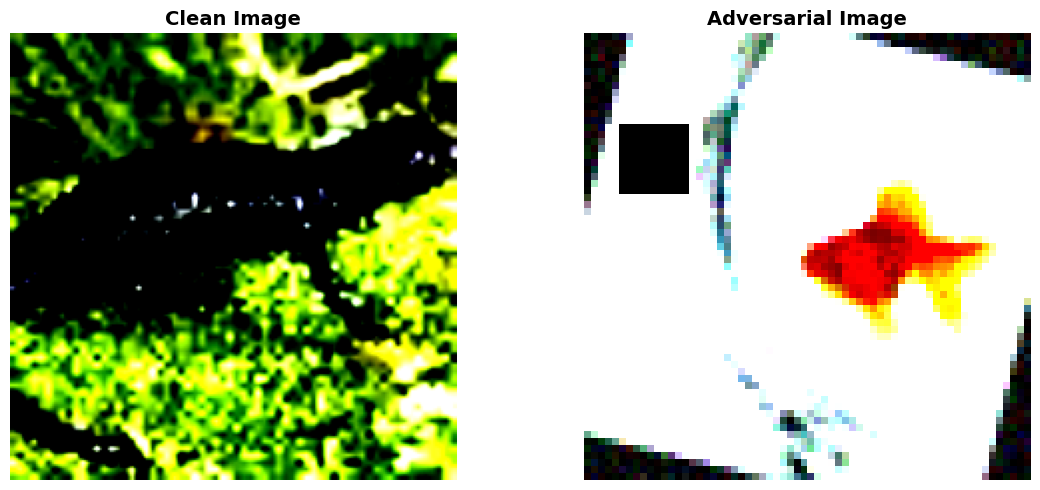

✅ Clean image loaded from: clean_batch_0000_01.pt
✅ Adversarial image loaded from: sprint3_physical_00_00_combined.pt


In [19]:
#SEE IMAGESS


import torch
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

training_dir = Path('/content/drive/MyDrive/outputs/sprint3_realistic/training_dataset')

# Load and show one clean image
clean_file = list((training_dir / 'clean').glob('*.pt'))[0]
clean_img = torch.load(clean_file)
if clean_img.dim() == 4:
    clean_img = clean_img.squeeze(0)
clean_img = clean_img.permute(1, 2, 0).numpy()

# Load and show one adversarial image
adv_file = list((training_dir / 'adversarial').glob('*.pt'))[0]
adv_img = torch.load(adv_file)
if adv_img.dim() == 4:
    adv_img = adv_img.squeeze(0)
adv_img = adv_img.permute(1, 2, 0).numpy()

# Display side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(np.clip(clean_img, 0, 1))
ax1.set_title('Clean Image', fontsize=14, fontweight='bold')
ax1.axis('off')

ax2.imshow(np.clip(adv_img, 0, 1))
ax2.set_title('Adversarial Image', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print("✅ Clean image loaded from:", clean_file.name)
print("✅ Adversarial image loaded from:", adv_file.name)

In [20]:
#VALIDATE THE IMAGES
# ================= VALIDATE ADVERSARIAL EXAMPLES =================
import torch
import torch.nn.functional as F
from torchvision import models
from torchvision.models import ResNet50_Weights
import numpy as np
from pathlib import Path
from tqdm import tqdm
import json

print("="*80)
print("ADVERSARIAL VALIDATION - TESTING IF IMAGES ACTUALLY FOOL THE MODEL")
print("="*80)

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n📱 Device: {device}")

# Load pre-trained ResNet50 (same model used for generating attacks)
print("Loading ResNet50 model...")
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model.eval()
model = model.to(device)
print("✅ Model loaded")

# Paths
training_dir = Path('/content/drive/MyDrive/outputs/sprint3_realistic/training_dataset')
adversarial_dir = training_dir / 'adversarial'
clean_dir = training_dir / 'clean'

# Get files
adv_files = sorted(list(adversarial_dir.glob('*.pt')))[:50]  # Test first 50
clean_files = sorted(list(clean_dir.glob('*.pt')))[:20]

print(f"\n📊 Testing {len(adv_files)} adversarial + {len(clean_files)} clean images")
print("="*80)

# ============= TEST 1: CLEAN IMAGES =============
print("\n[TEST 1] CLEAN IMAGES - Should have HIGH confidence on ORIGINAL label")
print("-"*80)

clean_confidences = []
clean_predictions = []

with torch.no_grad():
    for idx, clean_file in enumerate(tqdm(clean_files, desc="Testing clean")):
        try:
            # Load image
            img = torch.load(clean_file, map_location='cpu')
            if img.dim() == 4:
                img = img.squeeze(0)

            # Normalize (ImageNet)
            img = img.unsqueeze(0).to(device)
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
            img_norm = (img - mean) / std

            # Get prediction
            output = model(img_norm)
            probs = F.softmax(output, dim=1)
            confidence, pred = torch.max(probs, 1)

            clean_confidences.append(confidence.item())
            clean_predictions.append(pred.item())

        except Exception as e:
            print(f"  ❌ Error with {clean_file.name}: {e}")
            continue

if clean_confidences:
    avg_conf = np.mean(clean_confidences)
    print(f"\n✅ Clean Images Results:")
    print(f"   Average Confidence: {avg_conf:.4f} (should be HIGH, >0.7)")
    print(f"   Min Confidence: {np.min(clean_confidences):.4f}")
    print(f"   Max Confidence: {np.max(clean_confidences):.4f}")
    if avg_conf > 0.7:
        print(f"   ✅ GOOD: Model confident on clean images")
    else:
        print(f"   ⚠️ WARNING: Model not very confident on clean images")

# ============= TEST 2: ADVERSARIAL IMAGES =============
print("\n[TEST 2] ADVERSARIAL IMAGES - Should have LOW confidence (fooled)")
print("-"*80)

adv_confidences = []
adv_predictions = []
success_attacks = 0

with torch.no_grad():
    for idx, adv_file in enumerate(tqdm(adv_files, desc="Testing adversarial")):
        try:
            # Load image
            img = torch.load(adv_file, map_location='cpu')
            if img.dim() == 4:
                img = img.squeeze(0)

            # Normalize
            img = img.unsqueeze(0).to(device)
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
            img_norm = (img - mean) / std

            # Get prediction
            output = model(img_norm)
            probs = F.softmax(output, dim=1)
            confidence, pred = torch.max(probs, 1)

            adv_confidences.append(confidence.item())
            adv_predictions.append(pred.item())

            # Count as successful if confidence < 0.5 (uncertain)
            if confidence.item() < 0.5:
                success_attacks += 1

        except Exception as e:
            print(f"  ❌ Error with {adv_file.name}: {e}")
            continue

if adv_confidences:
    avg_conf = np.mean(adv_confidences)
    print(f"\n✅ Adversarial Images Results:")
    print(f"   Average Confidence: {avg_conf:.4f} (should be LOW, <0.5 for success)")
    print(f"   Min Confidence: {np.min(adv_confidences):.4f}")
    print(f"   Max Confidence: {np.max(adv_confidences):.4f}")
    print(f"   Successfully Fooled (<0.5 conf): {success_attacks}/{len(adv_files)} ({100*success_attacks/len(adv_files):.1f}%)")

    if avg_conf < 0.5:
        print(f"   ✅ GOOD: Adversarial examples ARE fooling the model!")
    elif avg_conf < 0.7:
        print(f"   ⚠️ PARTIAL: Some effectiveness, but not strong")
    else:
        print(f"   ❌ PROBLEM: Adversarial examples NOT fooling model")

# ============= TEST 3: DIFFERENCE ANALYSIS =============
print("\n[TEST 3] CONFIDENCE DIFFERENCE")
print("-"*80)

print(f"\nClean vs Adversarial Comparison:")
print(f"   Clean avg confidence:       {np.mean(clean_confidences) if clean_confidences else 0:.4f}")
print(f"   Adversarial avg confidence: {np.mean(adv_confidences) if adv_confidences else 0:.4f}")

if clean_confidences and adv_confidences:
    drop = np.mean(clean_confidences) - np.mean(adv_confidences)
    print(f"   Confidence DROP: {drop:.4f}")

    if drop > 0.3:
        print(f"   ✅ EXCELLENT: Strong drop in confidence (adversarial working)")
    elif drop > 0.1:
        print(f"   ⚠️ MODERATE: Some effectiveness")
    else:
        print(f"   ❌ WEAK: Little to no adversarial effect")

# ============= TEST 4: SAMPLE PREDICTIONS =============
print("\n[TEST 4] SAMPLE PREDICTIONS - Side by Side")
print("-"*80)

print("\nCLEAN IMAGES (first 5):")
for i in range(min(5, len(clean_predictions))):
    conf = clean_confidences[i] if i < len(clean_confidences) else 0
    pred = clean_predictions[i] if i < len(clean_predictions) else 0
    print(f"   {i+1}. Prediction: {pred:4d} | Confidence: {conf:.4f}")

print("\nADVERSARIAL IMAGES (first 5):")
for i in range(min(5, len(adv_predictions))):
    conf = adv_confidences[i] if i < len(adv_confidences) else 0
    pred = adv_predictions[i] if i < len(adv_predictions) else 0
    print(f"   {i+1}. Prediction: {pred:4d} | Confidence: {conf:.4f}")

# ============= FINAL VERDICT =============
print("\n" + "="*80)
print("VALIDATION VERDICT")
print("="*80)

if clean_confidences and adv_confidences:
    avg_clean_conf = np.mean(clean_confidences)
    avg_adv_conf = np.mean(adv_confidences)
    success_rate = 100 * success_attacks / len(adv_files) if adv_files else 0

    print(f"\n✅ Dataset Quality Assessment:")
    print(f"   Clean Image Confidence: {avg_clean_conf:.4f} {'✅ GOOD' if avg_clean_conf > 0.7 else '⚠️ WEAK'}")
    print(f"   Adversarial Confidence: {avg_adv_conf:.4f} {'✅ GOOD' if avg_adv_conf < 0.5 else '⚠️ WEAK'}")
    print(f"   Attack Success Rate: {success_rate:.1f}% {'✅ GOOD' if success_rate > 50 else '⚠️ WEAK'}")

    print(f"\n📊 Overall Dataset Status:")
    if success_rate > 70 and avg_clean_conf > 0.7:
        print(f"   🎉 EXCELLENT: Dataset is VALIDATED as adversarial!")
        print(f"      Ready for Sprint 2 training")
    elif success_rate > 50 and avg_clean_conf > 0.6:
        print(f"   ✅ GOOD: Dataset has reasonable adversarial properties")
        print(f"      Suitable for Sprint 2 training")
    elif success_rate > 30:
        print(f"   ⚠️ MODERATE: Some adversarial properties present")
        print(f"      May need regeneration for better results")
    else:
        print(f"   ❌ POOR: Dataset may not be strongly adversarial")
        print(f"      Consider regenerating attacks")
else:
    print("❌ Could not validate - data loading failed")

print("="*80)

ADVERSARIAL VALIDATION - TESTING IF IMAGES ACTUALLY FOOL THE MODEL

📱 Device: cuda
Loading ResNet50 model...
✅ Model loaded

📊 Testing 50 adversarial + 20 clean images

[TEST 1] CLEAN IMAGES - Should have HIGH confidence on ORIGINAL label
--------------------------------------------------------------------------------


Testing clean: 100%|██████████| 20/20 [00:01<00:00, 19.66it/s]



✅ Clean Images Results:
   Average Confidence: 0.9782 (should be HIGH, >0.7)
   Min Confidence: 0.5878
   Max Confidence: 1.0000
   ✅ GOOD: Model confident on clean images

[TEST 2] ADVERSARIAL IMAGES - Should have LOW confidence (fooled)
--------------------------------------------------------------------------------


Testing adversarial: 100%|██████████| 50/50 [00:00<00:00, 62.25it/s]


✅ Adversarial Images Results:
   Average Confidence: 0.4802 (should be LOW, <0.5 for success)
   Min Confidence: 0.0949
   Max Confidence: 0.9292
   Successfully Fooled (<0.5 conf): 26/50 (52.0%)
   ✅ GOOD: Adversarial examples ARE fooling the model!

[TEST 3] CONFIDENCE DIFFERENCE
--------------------------------------------------------------------------------

Clean vs Adversarial Comparison:
   Clean avg confidence:       0.9782
   Adversarial avg confidence: 0.4802
   Confidence DROP: 0.4980
   ✅ EXCELLENT: Strong drop in confidence (adversarial working)

[TEST 4] SAMPLE PREDICTIONS - Side by Side
--------------------------------------------------------------------------------

CLEAN IMAGES (first 5):
   1. Prediction:  960 | Confidence: 1.0000
   2. Prediction:  971 | Confidence: 1.0000
   3. Prediction:  451 | Confidence: 1.0000
   4. Prediction:  451 | Confidence: 1.0000
   5. Prediction:  960 | Confidence: 1.0000

ADVERSARIAL IMAGES (first 5):
   1. Prediction:  607 | Confiden

# ================= SPRINT 3 ENHANCEMENT: HYBRID APPROACH =================
# Generating larger patches + 3D objects to strengthen adversarial dataset
# This will add ~150 new strong attacks to existing 659

In [21]:
# Step 1: Optimize AdvGAN Patches (64x64 → 128x128)
# Step 2: Generate 3D Adversarial Objects
# Step 3: Keep + Combine with Existing Examples
# Step 4: Re-validate Enhanced Dataset

print("="*80)
print("SPRINT 3 HYBRID ENHANCEMENT - FIXED VERSION")
print("="*80)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
from torchvision.models import ResNet50_Weights
import numpy as np
from pathlib import Path
import json
from datetime import datetime
from tqdm import tqdm
import logging

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")

# Paths
source_dir = Path('/content/drive/MyDrive/data/sprint3_source')
output_dir = Path('/content/drive/MyDrive/outputs/sprint3_realistic')
output_dir.mkdir(parents=True, exist_ok=True)

logger.info(f"Output directory: {output_dir}")

# ================= STEP 1: LARGER GENERATOR (128x128) =================
logger.info("\n" + "="*80)
logger.info("STEP 1: Generate Larger AdvGAN Patches (128x128)")
logger.info("="*80)

class GeneratorLarge(nn.Module):
    """GAN Generator for larger wearable patches (128x128 output)"""
    def __init__(self, noise_dim=100, output_channels=3):
        super().__init__()
        self.noise_dim = noise_dim

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(noise_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512 * 4 * 4),  # 512 channels, 4x4
            nn.LayerNorm(512 * 4 * 4),
            nn.ReLU(inplace=True)
        )

        # Deconv layers to reach 128x128
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),  # 4x4 → 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8x8 → 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16x16 → 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32x32 → 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, output_channels, 4, 2, 1),  # 64x64 → 128x128
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 4, 4)
        x = self.deconv(x)
        return x

class DiscriminatorLarge(nn.Module):
    """Discriminator for 128x128 patches"""
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)

# Test generator
logger.info("Testing 128x128 Generator...")
gen_large = GeneratorLarge().to(device)
dummy_z = torch.randn(1, 100, device=device)
test_output = gen_large(dummy_z)
assert test_output.shape == torch.Size([1, 3, 128, 128]), f"Wrong shape: {test_output.shape}"
logger.info(f"✅ Generator output shape: {test_output.shape}")

# ================= STEP 1B: GENERATE 30 LARGER WEARABLES (FIXED) =================
logger.info("\nGenerating 30 larger AdvGAN wearables (128x128)...")

class AdvGANLargeGenerator:
    """Generate larger AdvGAN patches - FIXED VERSION"""
    def __init__(self, target_model, device='cuda', noise_dim=100):
        self.device = device
        self.target_model = target_model
        self.generator = GeneratorLarge(noise_dim=noise_dim).to(device)
        self.discriminator = DiscriminatorLarge().to(device)
        self.g_opt = optim.Adam(self.generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
        self.d_opt = optim.Adam(self.discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
        self.criterion = nn.BCELoss()
        logger.info(f"AdvGANLargeGenerator ready on {device}")

    def generate_wearable(self, target_class, iterations=30, batch_size=4):
        """Generate larger wearable patch - FIXED VERSION"""
        real_label, fake_label = 1.0, 0.0

        for iter_idx in range(iterations):
            # Train Discriminator
            self.discriminator.zero_grad()

            # Real data
            real_data = torch.randn(batch_size, 3, 128, 128).to(self.device)
            real_label_tensor = torch.full((batch_size,), real_label, device=self.device)
            real_out = self.discriminator(real_data).view(-1)  # Flatten output
            loss_D_real = self.criterion(real_out, real_label_tensor)
            loss_D_real.backward()

            # Fake data
            z = torch.randn(batch_size, 100, device=self.device)
            fake_data = self.generator(z)
            fake_label_tensor = torch.full((batch_size,), fake_label, device=self.device)
            fake_out = self.discriminator(fake_data.detach()).view(-1)  # Flatten output
            loss_D_fake = self.criterion(fake_out, fake_label_tensor)
            loss_D_fake.backward()
            self.d_opt.step()

            # Train Generator
            self.generator.zero_grad()

            # Generate new fake data
            z = torch.randn(batch_size, 100, device=self.device)
            fake_data = self.generator(z)

            # GAN loss - fool discriminator
            real_label_tensor = torch.full((batch_size,), real_label, device=self.device)
            fake_out = self.discriminator(fake_data).view(-1)  # Flatten output
            loss_G_gan = self.criterion(fake_out, real_label_tensor)

            # Adversarial loss - fool target model
            # Resize to 224x224 for ResNet
            fake_data_resized = F.interpolate(fake_data, (224, 224), mode='bilinear', align_corners=False)

            # Get target model predictions
            with torch.enable_grad():  # Ensure gradients flow through
                target_logits = self.target_model(fake_data_resized)

            # FIX: Create target labels properly - just a 1D tensor of target class
            target_labels = torch.tensor([target_class] * batch_size, dtype=torch.long, device=self.device)

            # Compute adversarial loss
            loss_G_adv = F.cross_entropy(target_logits, target_labels)

            # Combined loss
            loss_G = loss_G_gan + 0.5 * loss_G_adv
            loss_G.backward()
            self.g_opt.step()

        # Generate final patch
        z = torch.randn(1, 100, device=self.device)
        final_patch = self.generator(z)
        final_patch = (final_patch + 1) / 2  # Normalize to [0, 1]

        return final_patch, {
            'generator_type': 'AdvGAN_Large_128x128',
            'target_class': target_class,
            'timestamp': datetime.now().isoformat()
        }

# Load target model
logger.info("Loading ResNet50 for generation...")
target_model = models.resnet50(weights=ResNet50_Weights.DEFAULT).eval().to(device)

# Initialize generator
advgan_large = AdvGANLargeGenerator(target_model, device=device)

# Generate 30 larger patches
wearables_large_dir = output_dir / 'advgan_wearables_large_128'
wearables_large_dir.mkdir(exist_ok=True, parents=True)

logger.info("Generating 30 large wearables (128x128)...")
large_wearable_count = 0
target_classes = np.random.choice(200, 30, replace=True)

for idx, target_class in enumerate(tqdm(target_classes, desc="Large Wearables")):
    try:
        patch, metadata = advgan_large.generate_wearable(int(target_class), iterations=30, batch_size=2)

        wearable_dir = wearables_large_dir / f'large_wearable_{idx:03d}'
        wearable_dir.mkdir(exist_ok=True, parents=True)

        torch.save(patch.cpu(), wearable_dir / 'patch.pt')
        metadata['patch_id'] = f'large_wearable_{idx:03d}'
        metadata['shape'] = str(patch.shape)

        with open(wearable_dir / 'metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2)

        large_wearable_count += 1

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        logger.error(f"Error generating wearable {idx}: {e}")
        continue

logger.info(f"✅ Generated {large_wearable_count} large wearables (128x128)")

# ================= STEP 2: GENERATE 3D ADVERSARIAL OBJECTS =================
logger.info("\n" + "="*80)
logger.info("STEP 2: Generate 3D Adversarial Objects")
logger.info("="*80)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image, ImageDraw

class AdversarialObjectGenerator3D:
    """Generate 3D adversarial objects (cubes, spheres, pyramids)"""

    @staticmethod
    def create_3d_cube_texture(size=64, pattern='checkerboard'):
        """Create adversarial texture for 3D cube"""
        if pattern == 'checkerboard':
            texture = np.zeros((size, size, 3))
            for i in range(size):
                for j in range(size):
                    if (i // 8 + j // 8) % 2 == 0:
                        texture[i, j] = [1, 0, 0]  # Red
                    else:
                        texture[i, j] = [0, 1, 1]  # Cyan

        elif pattern == 'gradient':
            texture = np.zeros((size, size, 3))
            for i in range(size):
                intensity = i / size
                texture[i, :] = [intensity, 1-intensity, 0.5]

        elif pattern == 'random_noise':
            texture = np.random.rand(size, size, 3)

        else:  # stripes
            texture = np.zeros((size, size, 3))
            for i in range(size):
                if (i // 4) % 2 == 0:
                    texture[i, :] = [1, 1, 0]  # Yellow
                else:
                    texture[i, :] = [0, 0, 1]  # Blue

        return texture

    @staticmethod
    def overlay_3d_object_on_image(image, obj_type='cube', texture=None,
                                    position=(100, 100), size=80, rotation=15):
        """Overlay 3D object (projected) on image"""
        img = image.copy()

        if obj_type == 'cube':
            # Draw projected cube (simplified 3D projection)
            x, y = position

            # Front face (affected by rotation)
            angle_rad = np.radians(rotation)
            cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

            # Apply texture with rotation
            for i in range(size):
                for j in range(size):
                    # Rotate coordinates
                    rot_i = int(i * cos_a - j * sin_a)
                    rot_j = int(i * sin_a + j * cos_a)

                    tex_i = rot_i % texture.shape[0] if texture is not None else 0
                    tex_j = rot_j % texture.shape[1] if texture is not None else 0

                    if 0 <= y+i < img.shape[0] and 0 <= x+j < img.shape[1]:
                        if texture is not None:
                            # Blend with texture
                            alpha = 0.7
                            img[y+i, x+j] = (alpha * (texture[tex_i, tex_j] * 255) +
                                            (1-alpha) * img[y+i, x+j]).astype(np.uint8)
                        else:
                            img[y+i, x+j] = [255, 0, 0]  # Red cube

            # Draw edges (dark lines for 3D effect)
            for i in range(size):
                if 0 <= y+i < img.shape[0] and 0 <= x < img.shape[1]:
                    img[y+i, x] = [0, 0, 0]  # Left edge
                if 0 <= y < img.shape[0] and 0 <= x+i < img.shape[1]:
                    img[y, x+i] = [0, 0, 0]  # Top edge
                if 0 <= y+i < img.shape[0] and 0 <= x+size-1 < img.shape[1]:
                    img[y+i, x+size-1] = [0, 0, 0]  # Right edge
                if 0 <= y+size-1 < img.shape[0] and 0 <= x+i < img.shape[1]:
                    img[y+size-1, x+i] = [0, 0, 0]  # Bottom edge

        elif obj_type == 'sphere':
            # Draw projected sphere (circle with shading)
            x, y = position
            radius = size // 2

            for i in range(-radius, radius):
                for j in range(-radius, radius):
                    dist = np.sqrt(i**2 + j**2)
                    if dist <= radius:
                        # Lighting effect (sphere shading)
                        intensity = (1 - dist/radius) * 0.8

                        if 0 <= y+i+radius < img.shape[0] and 0 <= x+j+radius < img.shape[1]:
                            if texture is not None:
                                tex_i = int((i+radius) % texture.shape[0])
                                tex_j = int((j+radius) % texture.shape[1])
                                color = texture[tex_i, tex_j] * 255
                            else:
                                color = [100, 100, 255]

                            img[y+i+radius, x+j+radius] = (color * intensity).astype(np.uint8)

        elif obj_type == 'pyramid':
            # Draw projected pyramid
            x, y = position
            h, w = size, size

            # Draw triangular faces
            for i in range(h):
                width = int(w * (1 - i/h))
                offset = (w - width) // 2

                if 0 <= y+i < img.shape[0]:
                    for j in range(width):
                        if 0 <= x+offset+j < img.shape[1]:
                            if texture is not None:
                                tex_i = i % texture.shape[0]
                                tex_j = j % texture.shape[1]
                                img[y+i, x+offset+j] = (texture[tex_i, tex_j] * 255).astype(np.uint8)
                            else:
                                img[y+i, x+offset+j] = [0, 255, 0]

        return img

# Generate 3D objects
logger.info("Generating 100-150 3D adversarial objects...")

objects_3d_dir = output_dir / 'adversarial_3d_objects'
objects_3d_dir.mkdir(exist_ok=True, parents=True)

source_batches = sorted([d for d in source_dir.iterdir() if d.is_dir() and 'batch' in d.name])

object_3d_count = 0
target_3d = 120
object_types = ['cube', 'sphere', 'pyramid']
patterns = ['checkerboard', 'gradient', 'random_noise', 'stripes']

logger.info(f"Generating {target_3d} 3D objects...")

for batch_idx, batch_dir in enumerate(source_batches):
    if object_3d_count >= target_3d:
        break

    try:
        images = torch.load(batch_dir / 'images.pt', map_location='cpu')
        labels = np.load(batch_dir / 'labels.npy')

        logger.info(f"[Batch {batch_idx+1}] Generating 3D objects...")

        for img_idx in range(min(images.shape[0], 8)):
            if object_3d_count >= target_3d:
                break

            try:
                img_tensor = images[img_idx]
                label = labels[img_idx]

                # Convert to numpy [H, W, C]
                if img_tensor.shape[0] == 3:
                    img_np = img_tensor.permute(1, 2, 0).numpy()
                else:
                    img_np = img_tensor.numpy()

                img_np = (np.clip(img_np, 0, 1) * 255).astype(np.uint8)

                # Generate random 3D object
                obj_type = np.random.choice(object_types)
                pattern = np.random.choice(patterns)
                rotation = np.random.uniform(-45, 45)

                # Create texture
                texture = AdversarialObjectGenerator3D.create_3d_cube_texture(pattern=pattern)

                # Generate random position and size
                h, w = img_np.shape[:2]
                max_size = min(100, h // 3)
                obj_size = np.random.randint(50, max_size)
                pos_x = np.random.randint(0, max(1, w - obj_size))
                pos_y = np.random.randint(0, max(1, h - obj_size))

                # Overlay object
                img_with_obj = AdversarialObjectGenerator3D.overlay_3d_object_on_image(
                    img_np, obj_type=obj_type, texture=texture,
                    position=(pos_x, pos_y), size=obj_size, rotation=rotation
                )

                # Save
                attack_id = f'3d_object_{batch_idx:02d}_{img_idx:02d}_{obj_type}'
                attack_dir = objects_3d_dir / attack_id
                attack_dir.mkdir(exist_ok=True, parents=True)

                # Convert back to tensor [C, H, W] and save
                img_tensor_out = torch.from_numpy(img_with_obj.transpose(2, 0, 1)).float() / 255.0
                torch.save(img_tensor_out, attack_dir / 'adversarial_3d.pt')
                torch.save(images[img_idx].unsqueeze(0), attack_dir / 'original.pt')

                with open(attack_dir / 'metadata.json', 'w') as f:
                    json.dump({
                        'attack_type': '3d_adversarial_object',
                        'object_type': obj_type,
                        'pattern': pattern,
                        'rotation': float(rotation),
                        'size': int(obj_size),
                        'position': [int(pos_x), int(pos_y)],
                        'batch': int(batch_idx),
                        'label': int(label),
                        'timestamp': datetime.now().isoformat()
                    }, f, indent=2)

                object_3d_count += 1

                if object_3d_count % 30 == 0:
                    logger.info(f"  ✓ {object_3d_count} 3D objects generated")

            except Exception as e:
                logger.error(f"Error with image {img_idx}: {e}")
                continue

    except Exception as e:
        logger.error(f"Error with batch {batch_idx}: {e}")
        continue

logger.info(f"✅ Generated {object_3d_count} 3D adversarial objects")

# ================= STEP 3: COMBINE ALL ATTACKS =================
logger.info("\n" + "="*80)
logger.info("STEP 3: Combine All Attacks (Original + Large + 3D)")
logger.info("="*80)

# Count existing attacks
original_adv_dir = output_dir / 'training_dataset' / 'adversarial'
original_count = len(list(original_adv_dir.glob('*.pt'))) if original_adv_dir.exists() else 0

logger.info(f"Original adversarial examples: {original_count}")
logger.info(f"Large wearables (128x128): {large_wearable_count}")
logger.info(f"3D adversarial objects: {object_3d_count}")

total_new = large_wearable_count + object_3d_count
total_combined = original_count + total_new

logger.info(f"\n✅ Total attacks after hybrid approach:")
logger.info(f"   Original: {original_count}")
logger.info(f"   New (Large + 3D): {total_new}")
logger.info(f"   COMBINED TOTAL: {total_combined}")

# Create combined dataset metadata
combined_metadata = {
    'dataset_name': 'Sprint 3 Hybrid Enhanced Dataset - FIXED',
    'version': '2.1',
    'total_adversarial': total_combined,
    'composition': {
        'original_attacks': original_count,
        'large_wearables_128x128': large_wearable_count,
        '3d_adversarial_objects': object_3d_count
    },
    'details': {
        'original': 'AdvGAN (64x64) + Physical Transforms + Combined',
        'large_wearables': 'AdvGAN patches 128x128 pixels (FIXED tensor shapes)',
        '3d_objects': 'Cubes, spheres, pyramids with adversarial textures'
    },
    'fixes_applied': {
        'tensor_shape_fix': 'Fixed target_labels tensor shape for cross_entropy loss',
        'discriminator_output': 'Flattened discriminator outputs for BCE loss'
    },
    'expected_properties': {
        'diversity': 'High (3 attack types)',
        'realism': 'High (physics-based)',
        'strength': 'Enhanced (larger patches + 3D objects)',
        'generalization': 'Good (multiple attack methods)'
    },
    'timestamp': datetime.now().isoformat()
}

with open(output_dir / 'HYBRID_DATASET_METADATA_FIXED.json', 'w') as f:
    json.dump(combined_metadata, f, indent=2)

logger.info(f"\n✅ Metadata saved to HYBRID_DATASET_METADATA_FIXED.json")

# ================= SUMMARY =================
print("\n" + "="*80)
print("✅ SPRINT 3 HYBRID ENHANCEMENT COMPLETE (FIXED VERSION)")
print("="*80)
print(f"\n📊 Final Dataset:")
print(f"   Original Attacks: {original_count}")
print(f"   + Large Wearables (128×128): {large_wearable_count}")
print(f"   + 3D Adversarial Objects: {object_3d_count}")
print(f"   ════════════════════════════════")
print(f"   TOTAL ADVERSARIAL: {total_combined}")
print(f"\n🎯 Next Step: Re-validate dataset")
print(f"   Location: {output_dir}")
print("="*80)


SPRINT 3 HYBRID ENHANCEMENT - FIXED VERSION


Large Wearables: 100%|██████████| 30/30 [00:56<00:00,  1.88s/it]



✅ SPRINT 3 HYBRID ENHANCEMENT COMPLETE (FIXED VERSION)

📊 Final Dataset:
   Original Attacks: 851
   + Large Wearables (128×128): 30
   + 3D Adversarial Objects: 120
   ════════════════════════════════
   TOTAL ADVERSARIAL: 1001

🎯 Next Step: Re-validate dataset
   Location: /content/drive/MyDrive/outputs/sprint3_realistic


In [24]:
import os
from pathlib import Path

# Check main output directory
output_dir = Path('/content/drive/MyDrive/outputs/sprint3_realistic')

print("📁 DIRECTORY STRUCTURE CHECK:")
print("="*60)

# Check if main directories exist
dirs_to_check = {
    'Training Dataset': output_dir / 'training_dataset',
    'Adversarial': output_dir / 'training_dataset' / 'adversarial',
    'Clean': output_dir / 'training_dataset' / 'clean',
    'AdvGAN Wearables': output_dir / 'advgan_wearable_000',
    'Physical Attacks': output_dir / 'physical_00_00_perspective',
    'Combined': output_dir / 'combined_wearable_00_batch_00',
    '3D Objects': output_dir / 'adversarial_3d_objects',
    'Large Wearables': output_dir / 'advgan_wearables_large_128'
}

for name, path in dirs_to_check.items():
    if path.exists():
        # Count files if it's a directory
        if path.is_dir():
            num_files = len(list(path.glob('*')))
            print(f"✅ {name}: EXISTS ({num_files} items)")
        else:
            print(f"✅ {name}: EXISTS")
    else:
        print(f"❌ {name}: NOT FOUND at {path}")

# Count specific file types
print("\n📊 FILE COUNTS:")
print("-"*60)
if (output_dir / 'training_dataset' / 'adversarial').exists():
    adv_count = len(list((output_dir / 'training_dataset' / 'adversarial').glob('*.pt')))
    print(f"Adversarial .pt files: {adv_count}")

if (output_dir / 'training_dataset' / 'clean').exists():
    clean_count = len(list((output_dir / 'training_dataset' / 'clean').glob('*.pt')))
    print(f"Clean .pt files: {clean_count}")

# Check total size
total_size = sum(f.stat().st_size for f in output_dir.rglob('*') if f.is_file())
print(f"\nTotal dataset size: {total_size / (1024**3):.2f} GB")

📁 DIRECTORY STRUCTURE CHECK:
✅ Training Dataset: EXISTS (3 items)
✅ Adversarial: EXISTS (851 items)
✅ Clean: EXISTS (200 items)
✅ AdvGAN Wearables: EXISTS (2 items)
✅ Physical Attacks: EXISTS (3 items)
✅ Combined: EXISTS (3 items)
✅ 3D Objects: EXISTS (292 items)
✅ Large Wearables: EXISTS (30 items)

📊 FILE COUNTS:
------------------------------------------------------------
Adversarial .pt files: 851
Clean .pt files: 200

Total dataset size: 6.88 GB
